# 06. Реальные данные «Диабет» (442 пациента): бустинг против простых моделей

| | |
|---|---|
| **Уровень** | 2 из 4 — маленькие данные: реальные наборы и базовые приёмы (`2_small`) |
| **Скрипт-источник** | [`06_diabetes_regression.py`](../06_diabetes_regression.py) — тот же код, запуск из терминала |
| **Время выполнения** | ≈ 9 с |

**Цель.** Честно сравнить бустинг с базовыми моделями на маленьком реальном наборе и понять, почему бустинг не обязан выигрывать.

### Чему вы научитесь

- Разбор реального набора: признаки, масштаб, цель
- Базовые модели — константа и гребневая регрессия
- Повторная кросс-валидация и разброс оценок
- Настройка бустинга под маленькие данные

### Данные

`sklearn.datasets.load_diabetes` — 442 пациента, 10 признаков (возраст, пол, индекс массы тела, давление и 6 показателей крови), признаки уже центрированы и масштабированы; цель — прогрессия болезни через год (число 25…346). Встроен в scikit-learn, скачивать не нужно.

### План

1. **Этап 1.** Данные
2. **Этап 2.** Протокол: 5 фолдов × 3 повтора, метрика RMSE
3. **Этап 3.** Что получилось
4. **Этап 4.** Какие признаки важны (бустинг для малых данных, обученный на всех данных)
5. **Этап 5.** Вывод

> Ноутбук собран из `examples/2_small/06_diabetes_regression.py` командой `python examples/build_notebooks.py`. Чтобы изменить пример, правьте скрипт и пересоберите ноутбук.

## Подготовка

Ячейка ниже находит папку `examples/` (ноутбук можно открыть из любой рабочей папки внутри
репозитория), подключает общий каркас примеров `_common.Example` и учебную библиотеку курса
`gbcourse`. Каркас печатает этапы и выводы, «раскрывает» датасет и показывает графики прямо в
ноутбуке. Выполняйте ячейки сверху вниз: **Run → Run All Cells**.

In [1]:
import sys
from pathlib import Path

EXAMPLES = next(p / "examples" for p in [Path.cwd(), *Path.cwd().parents]
                if (p / "examples" / "_common.py").is_file())
sys.path.insert(0, str(EXAMPLES))
from _common import Example

ex = Example(EXAMPLES / "2_small/06_diabetes_regression.py", title="06. Реальные данные «Диабет»: бустинг против простых моделей",
             goal="сравнить модели по повторной кросс-валидации и сделать честный вывод")

import warnings

import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import RepeatedKFold, cross_val_score

warnings.filterwarnings("ignore")

## Этап 1. Данные

In [2]:
data = load_diabetes(as_frame=True)
X, y = data.data, data.target.to_numpy()
ex.describe(X, y, target="прогрессия болезни", source="sklearn.datasets.load_diabetes (Efron и др., 2004)")
ex.note("""Признаки уже центрированы и масштабированы (поэтому такие маленькие числа).
bmi — индекс массы тела, bp — давление, s1…s6 — показатели крови.""")

   Источник: sklearn.datasets.load_diabetes (Efron и др., 2004)
   Объектов: 442   признаков: 10   память: 0.03 МБ
   Типы признаков: float64 × 10
   Пропусков нет
   Цель «прогрессия болезни»: среднее 152.133, σ 77.006, мин 25.000, макс 346.000
   Первые строки:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,[прогрессия болезни]
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0


> ▸ **Вывод.** Признаки уже центрированы и масштабированы (поэтому такие маленькие числа). bmi — индекс массы тела, bp — давление, s1…s6 — показатели крови.

## Этап 2. Протокол: 5 фолдов × 3 повтора, метрика RMSE

In [3]:
cv = RepeatedKFold(n_splits=5, n_repeats=3, random_state=0)
models = {
    "константа (среднее)": DummyRegressor(),
    "гребневая регрессия": RidgeCV(alphas=np.logspace(-3, 3, 20)),
    "случайный лес": RandomForestRegressor(300, min_samples_leaf=5, random_state=0, n_jobs=-1),
    "бустинг по умолчанию": GradientBoostingRegressor(random_state=0),
    "бустинг для малых данных": GradientBoostingRegressor(n_estimators=300, learning_rate=0.02, max_depth=2,
                                                          subsample=0.8, random_state=0),
}
res = {}
for name, model in models.items():
    s = -cross_val_score(model, X, y, cv=cv, scoring="neg_root_mean_squared_error")
    res[name] = (s.mean(), s.std())
    print(f"   {name:26s} RMSE {s.mean():6.2f} ± {s.std():.2f}")

   константа (среднее)        RMSE  77.05 ± 2.99
   гребневая регрессия        RMSE  54.78 ± 2.68


   случайный лес              RMSE  56.46 ± 3.93


   бустинг по умолчанию       RMSE  58.15 ± 3.96


   бустинг для малых данных   RMSE  55.50 ± 3.54


## Этап 3. Что получилось

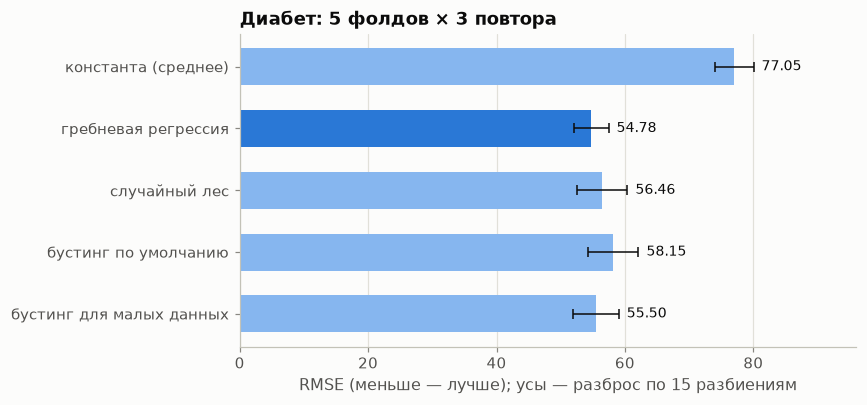

> ▸ **Вывод.** Гребневая регрессия — лучшая или не хуже лучшей: зависимость здесь почти линейная, а данных мало. Бустинг по умолчанию (100 деревьев глубины 3) хуже всех моделей, кроме константы: он переобучается на 350 объектах. Бустинг «для малых данных» (неглубокие деревья, маленький темп, подвыборка) почти догоняет линейную модель.

In [4]:
ex.barh({k: v[0] for k, v in res.items()}, errors={k: v[1] for k, v in res.items()}, best=min(res, key=lambda k: res[k][0]),
        xlabel="RMSE (меньше — лучше); усы — разброс по 15 разбиениям", title="Диабет: 5 фолдов × 3 повтора",
        name="06_models_rmse", fmt="{:.2f}")
ex.note("""Гребневая регрессия — лучшая или не хуже лучшей: зависимость здесь почти линейная, а данных мало.
Бустинг по умолчанию (100 деревьев глубины 3) хуже всех моделей, кроме константы: он переобучается на 350 объектах.
Бустинг «для малых данных» (неглубокие деревья, маленький темп, подвыборка) почти догоняет линейную модель.""")
assert res["гребневая регрессия"][0] <= res["бустинг по умолчанию"][0]
assert res["бустинг для малых данных"][0] < res["бустинг по умолчанию"][0]

## Этап 4. Какие признаки важны (бустинг для малых данных, обученный на всех данных)

In [5]:
gb = models["бустинг для малых данных"].fit(X, y)
for name, v in sorted(zip(X.columns, gb.feature_importances_), key=lambda t: -t[1])[:5]:
    print(f"   {name:4s} {v:.3f}")

   s5   0.376
   bmi  0.319
   bp   0.105
   s6   0.048
   s3   0.041


## Этап 5. Вывод

In [6]:
ex.note("""На маленьких данных с почти линейной зависимостью начинайте с линейной модели.
Бустинг силён там, где есть нелинейности и взаимодействия и достаточно данных (примеры 11–22).
Разброс оценок между разбиениями (±3–4) сравним с разницей между моделями — без повторной CV вывод был бы случайным.""")
ex.done()

> ▸ **Вывод.** На маленьких данных с почти линейной зависимостью начинайте с линейной модели. Бустинг силён там, где есть нелинейности и взаимодействия и достаточно данных (примеры 11–22). Разброс оценок между разбиениями (±3–4) сравним с разницей между моделями — без повторной CV вывод был бы случайным.

Готово за 7.9 с


## Попробуйте сами

Измените код в ячейках выше и выполните их заново:

1. Добавьте в сравнение HistGradientBoostingRegressor и LightGBM с параметрами по умолчанию.
2. Дайте гребневой регрессии попарные произведения признаков (PolynomialFeatures) — станет ли она ещё лучше?
3. Уменьшите темп бустинга до 0.01 и увеличьте число деревьев — изменится ли вывод сравнения?

## Что дальше

- **Теория в курсе:** [9.4 «Сравнение»](../../../lessons/lesson_9_4/README.md), [11.2 «CV и Optuna»](../../../lessons/lesson_11_2/README.md).
- **Предыдущий пример:** [05. Градиентный бустинг с нуля за 30 строк — и точное совпадение с scikit-learn](05_gbm_from_scratch.ipynb)
- **Следующий пример:** [07. Реальные данные «Рак груди» (569 опухолей): бинарная классификация и выбор порога](07_breast_cancer_classification.ipynb)
- **Все примеры:** [examples/README.md](../../README.md)